# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
print("Semua library berhasil di import!")

Semua library berhasil di import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    df_raw = pd.read_csv(url)
    print(f"Data mentah (Titanic) berhasil dimuat dari URL.")
except Exception as e:
    print(f"Error: Gagal memuat data dari URL. {e}")

# Tampilkan 5 baris pertama
print("\n5 Baris Pertama Data Mentah:")
print(df_raw.head())

# Tampilkan info dasar
print("\nInfo Data Mentah:")
df_raw.info()

Data mentah (Titanic) berhasil dimuat dari URL.

5 Baris Pertama Data Mentah:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# 2a. Cek Missing Values
print("\nJumlah Missing Values per Kolom:")
missing_values = df_raw.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))
print(f"\n⚠️ Ditemukan total {missing_values.sum()} missing values.")


Jumlah Missing Values per Kolom:
Cabin       687
Age         177
Embarked      2
dtype: int64

⚠️ Ditemukan total 866 missing values.


In [4]:
# 2b. Cek Duplikat
# (Kita cek duplikat berdasarkan 'PassengerId' atau 'Name' jika perlu, tapi baris utuh jarang)
duplicate_rows = df_raw.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {duplicate_rows}")
if duplicate_rows == 0:
    print("✅ Tidak ada baris duplikat (identik) dalam dataset.")


Jumlah Baris Duplikat: 0
✅ Tidak ada baris duplikat (identik) dalam dataset.


In [5]:
# 2c. Cek Statistik Deskriptif
print("\nStatistik Deskriptif (Kolom Numerik):")
print(df_raw.describe())


Statistik Deskriptif (Kolom Numerik):
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Text(0, 0.5, 'Jumlah Penumpang')

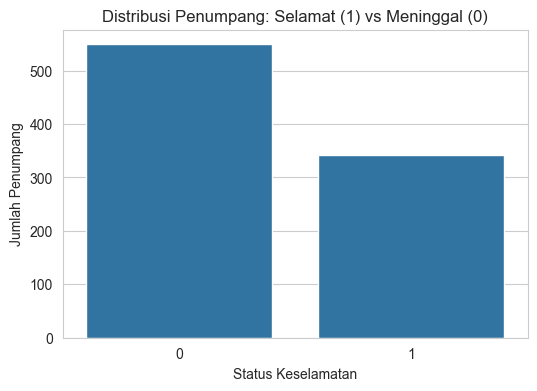

In [6]:
# Distribusi Target (Survived) 
# Untuk tahu seberapa seimbang data kita.
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df_raw)
plt.title('Distribusi Penumpang: Selamat (1) vs Meninggal (0)')
plt.xlabel('Status Keselamatan')
plt.ylabel('Jumlah Penumpang')

plot menunjukkan total penumpang untuk setiap kategori pada status keselamatan. jumlah data untuk kelas meninggal secara signifikan lebih banyak daripada kelas lainnya (selamat). bisa dikatakan data ini tidak seimbang (imbalanced). <br>
berikut kita observasi faktor yang mempengaruhi keselamatan para penumpang.

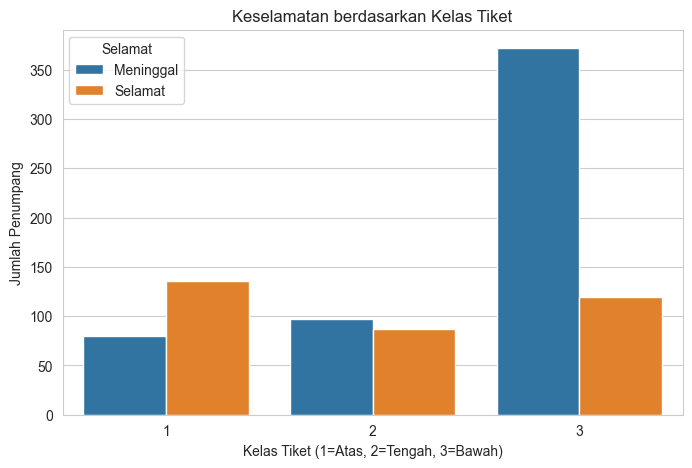

In [7]:
# keselamatan berdasarkan Kelas Tiket (Pclass)
# Apakah kelas sosial mempengaruhi keselamatan?
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df_raw)
plt.title('Keselamatan berdasarkan Kelas Tiket')
plt.xlabel('Kelas Tiket (1=Atas, 2=Tengah, 3=Bawah)')
plt.ylabel('Jumlah Penumpang')
plt.legend(title='Selamat', labels=['Meninggal', 'Selamat'])

penumpang kelas atas memiliki tingkat keselamatan paling tinggi, mayoritas dari mereka selamat. tingkat keselamatan di kelas menengah hampir 50/50, dengan sedikit lebih banyak yg meninggal. penumpang kelas bawah memiliki tingkat keselamatan yang paling rendah, sebagian besar dari mereka meninggal.

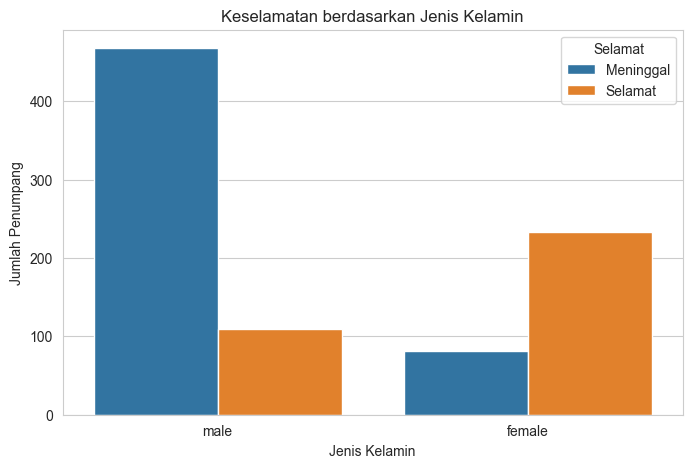

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='Survived', data=df_raw)
plt.title('Keselamatan berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah Penumpang')
plt.legend(title='Selamat', labels=['Meninggal', 'Selamat'])

kesimpulan : sebagian besar penumpang pria meninggal dan sebagian besar penumpang wanita selamat. jenis kelamin adalah faktor prediktor terkuat untuk menentukan keselamatan di titanic.

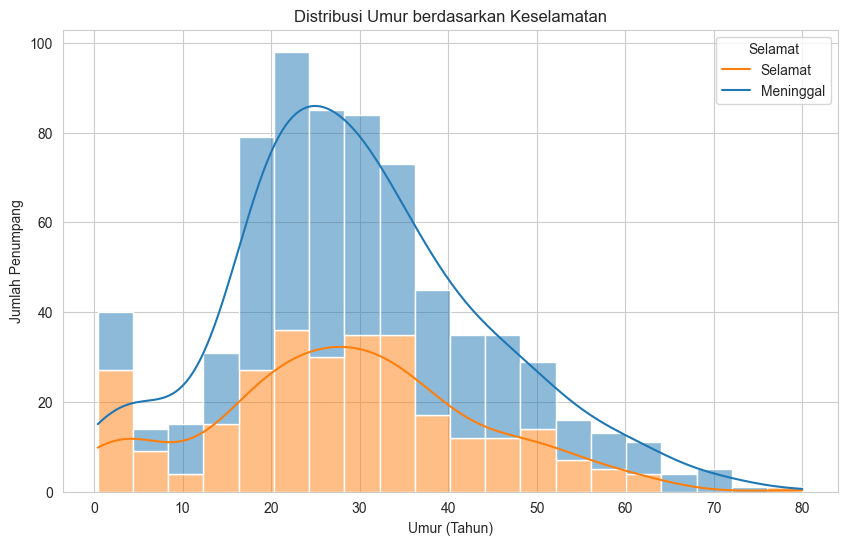

In [9]:
# distribusi umur 
# Ini penting untuk melihat data 'Age' yang banyak missing.
plt.figure(figsize=(10, 6))
sns.histplot(data=df_raw, x='Age', hue='Survived', kde=True, multiple="stack")
plt.title('Distribusi Umur berdasarkan Keselamatan')
plt.xlabel('Umur (Tahun)')
plt.ylabel('Jumlah Penumpang')
plt.legend(title='Selamat', labels=['Selamat', 'Meninggal'])

kesimpulan:
anak-anak kecil memiliki tingkat keselamatan yang jauh lebih tinggi dibandingkan dewasa muda dan lansia. dewasa muda (umur 18-40) memiliki tingkat kematian yang lebih tinggi karena mereka memberikan prioritas evakuasi kepada wanita dan anak-anak. ini berarti umur menjadi faktor penting yang signifikan dalam menentukan keselamatan di titanic

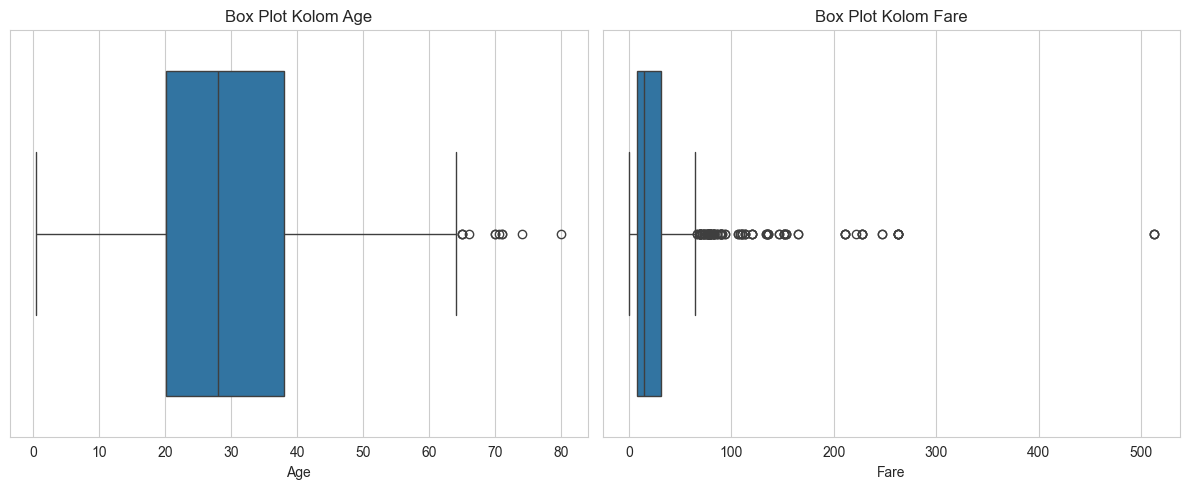

In [10]:
# deteksi outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(ax=axes[0], x=df_raw['Age'])
axes[0].set_title('Box Plot Kolom Age')
sns.boxplot(ax=axes[1], x=df_raw['Fare'])
axes[1].set_title('Box Plot Kolom Fare')
plt.tight_layout() 
plt.show()

kolom age tidak terlalu memiliki banyak outliern=, nilainya masih wajar, manusia bisa berumur 80. namun, di kolom fare memiliki outlier yang sangat ekstrem, sebagian besar penumpang membayar tiket murah, tapi beberapa yang membayar sangat mahal. 

Liat dulu apakah harga yang ekstrim berhubungan dengan kelas (pclass) karena harga yang dianggap outlier secara keseluruhan mungkin saja harga yang wajar untuk penumpang kelas atas.

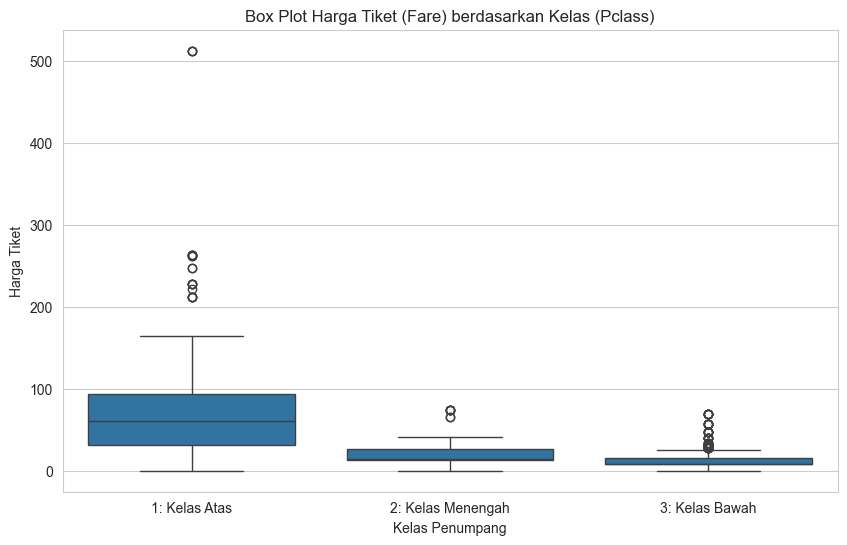

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_raw['Pclass'], y=df_raw['Fare'], order=[1, 2, 3])
plt.title('Box Plot Harga Tiket (Fare) berdasarkan Kelas (Pclass)')
plt.xlabel('Kelas Penumpang')
plt.ylabel('Harga Tiket')
plt.xticks(ticks=[0, 1, 2], labels=['1: Kelas Atas', '2: Kelas Menengah', '3: Kelas Bawah'])
plt.show()

nah, based on grafik di atas, kotak pclass 1 jelas jauh lebih tinggi dan lebar daripada pclass 2 dan 3, harga yg normal untuk pclass 1 adalah outlier pclass 2 dan 3. harga di atas 200-an itu memang outlier pclass 1, tp perhatikan ada 1 titik 512 yang merupakan outliernya. titik itu jauh sekali bahkan dari cluster outlier pclass 1. 

jadi kita akan melakukan capping, utk membuat model yang stabil dan generalisasi dengan baik, tiket 512 itu hanya ada 1 atau 2, tapi dampaknya ke scaler bisa sangat benar. dengan melakukan capping, ini membantu standardscaler bekerja lebih baik pada sebagian besar data.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# Buat salinan dataframe agar data mentah tidak berubah
df_clean = df_raw.copy()

In [13]:
# menangani missing values
# based on temuan EDA:
# strategi 1: drop Kolom 'Cabin' (karena > 70% datanya hilang)
df_clean = df_clean.drop(columns=['Cabin'])
print("Kolom 'Cabin' di-drop karena terlalu banyak null.")

# strategi 2: Imputasi 'Age' (numerik) dengan Median
# median lebih aman dari outlier dibanding Mean
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)
print(f"Missing values di 'Age' diisi dengan median: {median_age}")

# strategi 3: Imputasi 'Embarked' (kategorikal) dengan Modus
# hanya ada 2 baris yang null, kita isi dengan pelabuhan paling umum
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)
print(f"Missing values di 'Embarked' diisi dengan modus: {mode_embarked}")

# cek kembali missing values
print(f"\nJumlah null tersisa setelah preprocessing: {df_clean.isnull().sum().sum()}")
if df_clean.isnull().sum().sum() == 0:
    print("✅ Semua missing values telah ditangani.")

Kolom 'Cabin' di-drop karena terlalu banyak null.
Missing values di 'Age' diisi dengan median: 28.0
Missing values di 'Embarked' diisi dengan modus: S

Jumlah null tersisa setelah preprocessing: 0
✅ Semua missing values telah ditangani.


In [14]:
# menangani duplikat
if duplicate_rows > 0:
    # Menghapus duplikat dan memperbarui 'df'
    df_clean.drop_duplicates(inplace=True)
    
    # Mengatur ulang index setelah menghapus baris
    df_clean.reset_index(drop=True, inplace=True)
    
    print(f"Berhasil menghapus {jumlah_duplikat} baris duplikat.")
else:
    print("Tidak ada data duplikat untuk dihapus.")

Tidak ada data duplikat untuk dihapus.


In [15]:
# menangani outlier dengan metode capping
# 1. hitung Q1, Q3, dan IQR untuk kolom 'Fare'
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1

# 2. hitung batas atas dan batas bawah
batas_bawah = Q1 - (1.5 * IQR)
batas_atas = Q3 + (1.5 * IQR)

print(f"--- Statistik Asli 'Fare' ---")
print(f"Nilai Max Asli: {df_clean['Fare'].max()}")
print(f"Batas Atas IQR: {batas_atas}\n")

# 3. lakukan Capping
# gunakan np.clip() untuk 'menjepit' nilai.
# nilai < batas_bawah akan diubah jadi batas_bawah
# nilai > batas_atas akan diubah jadi batas_atas
df_clean['Fare'] = np.clip(df_raw['Fare'], batas_bawah, batas_atas)

print(f"--- Statistik Baru 'Fare' (Setelah Capping) ---")
print(f"Nilai Max Baru: {df_clean['Fare'].max()}")
print("Outlier di 'Fare' telah ditangani.")

--- Statistik Asli 'Fare' ---
Nilai Max Asli: 512.3292
Batas Atas IQR: 65.6344

--- Statistik Baru 'Fare' (Setelah Capping) ---
Nilai Max Baru: 65.6344
Outlier di 'Fare' telah ditangani.


In [16]:
# feature engineering / drop kolom yg tidak perlu
# kolom 'PassengerId', 'name', dan 'ticket' tidak banyak membantu model
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Kolom tidak relevan di-drop: {cols_to_drop}")

Kolom tidak relevan di-drop: ['PassengerId', 'Name', 'Ticket']


In [17]:
# encoding
# 1. ubah 'Sex' ('male', 'female') jadi angka (0, 1)
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# 2. ubah 'Embarked' (S, C, Q) pakai One-Hot Encoding
# cara mudah pakai Pandas: pd.get_dummies()
df_fix = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)
# drop_first=True untuk menghindari 'dummy variable trap'

print("\nData Setelah Encoding:")
print(df_fix.head())


Data Setelah Encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  65.6344       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


In [18]:
# normalisasi
# tentukan kolom mana yang mau di-scale
columns_to_scale = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# buat scaler-nya
scaler = StandardScaler()
df_fix[columns_to_scale] = scaler.fit_transform(df_fix[columns_to_scale])

print("\nData Setelah Normalisasi:")
print(df_fix.head())


Data Setelah Normalisasi:
   Survived    Pclass  Sex       Age     SibSp     Parch      Fare  \
0         0  0.827377    0 -0.565736  0.432793 -0.473674 -0.820552   
1         1 -1.566107    1  0.663861  0.432793 -0.473674  2.031623   
2         1  0.827377    1 -0.258337 -0.474545 -0.473674 -0.787578   
3         1 -1.566107    1  0.433312  0.432793 -0.473674  1.419297   
4         0  0.827377    0  0.433312 -0.474545 -0.473674 -0.781471   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


In [21]:
output_filename = 'titanic_preprocessing.csv'
df_fix.to_csv(output_filename, index=False)

print(f"\n✅ Proses Selesai!")
print(f"Dataset bersih telah disimpan sebagai: {output_filename}")
print(f"Bentuk data mentah: {df_raw.shape}")
print(f"Bentuk data bersih (setelah cleaning): {df_fix.shape}")

# Tampilkan 5 baris pertama dari data bersih untuk konfirmasi
print("\n5 Baris Pertama Data Bersih:")
print(df_fix.head())


✅ Proses Selesai!
Dataset bersih telah disimpan sebagai: titanic_preprocessing.csv
Bentuk data mentah: (891, 12)
Bentuk data bersih (setelah cleaning): (891, 9)

5 Baris Pertama Data Bersih:
   Survived    Pclass  Sex       Age     SibSp     Parch      Fare  \
0         0  0.827377    0 -0.565736  0.432793 -0.473674 -0.820552   
1         1 -1.566107    1  0.663861  0.432793 -0.473674  2.031623   
2         1  0.827377    1 -0.258337 -0.474545 -0.473674 -0.787578   
3         1 -1.566107    1  0.433312  0.432793 -0.473674  1.419297   
4         0  0.827377    0  0.433312 -0.474545 -0.473674 -0.781471   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  
